In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
#https://www.kaggle.com/datasets/spscientist/students-performance-in-exams

In [3]:
df = pd.read_csv("StudentsPerformance.csv")

In [4]:
df.head()

,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score
0,female,group B,bachelor's degree,standard,none,72,72,74
1,female,group C,some college,standard,completed,69,90,88
2,female,group B,master's degree,standard,none,90,95,93
3,male,group A,associate's degree,free/reduced,none,47,57,44
4,male,group C,some college,standard,none,76,78,75


In [5]:
df.isnull().sum()

gender                         0
race/ethnicity                 0
parental level of education    0
lunch                          0
test preparation course        0
math score                     0
reading score                  0
writing score                  0
dtype: int64

In [6]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 8 columns):
 #   Column                       Non-Null Count  Dtype
---  ------                       --------------  -----
 0   gender                       1000 non-null   str  
 1   race/ethnicity               1000 non-null   str  
 2   parental level of education  1000 non-null   str  
 3   lunch                        1000 non-null   str  
 4   test preparation course      1000 non-null   str  
 5   math score                   1000 non-null   int64
 6   reading score                1000 non-null   int64
 7   writing score                1000 non-null   int64
dtypes: int64(3), str(5)
memory usage: 62.6 KB


In [7]:
for col in df.columns:
    print(df[col].value_counts())
    print("----------------------------")

gender
female    518
male      482
Name: count, dtype: int64
----------------------------
race/ethnicity
group C    319
group D    262
group B    190
group E    140
group A     89
Name: count, dtype: int64
----------------------------
parental level of education
some college          226
associate's degree    222
high school           196
some high school      179
bachelor's degree     118
master's degree        59
Name: count, dtype: int64
----------------------------
lunch
standard        645
free/reduced    355
Name: count, dtype: int64
----------------------------
test preparation course
none         642
completed    358
Name: count, dtype: int64
----------------------------
math score
65    36
62    35
69    32
59    32
73    27
      ..
24     1
26     1
19     1
23     1
8      1
Name: count, Length: 81, dtype: int64
----------------------------
reading score
72    34
74    33
64    32
73    30
67    30
      ..
17     1
26     1
28     1
23     1
40     1
Name: count, Length: 7

In [8]:
# What i see is gender, lunch, test_prepration course can be convert to 0 and 1 using map method <- However how can i change in website input data??
# In race and parental level LabelEncoder or one hot encoder <- i know how to get label encoder so this is not a big deal

In [9]:
categorical_cols = df.select_dtypes(include=['str']).columns

In [10]:
numerical_cols = df.select_dtypes(include=['int64']).columns

In [11]:
numerical_cols

Index(['math score', 'reading score', 'writing score'], dtype='str')

In [12]:
import math

def plot_all_histograms(df,title_prefix=""):
    num_cols = df.select_dtypes(include=[np.number]).columns
    n_cols = 3
    n_rows = math.ceil(len(num_cols) / n_cols)

    plt.figure(figsize=(5*n_cols,4*n_rows))

    for i,col in enumerate(num_cols,1):
        plt.subplot(n_rows,n_cols,i)
        sns.histplot(df[col],kde=True,bins=30)
        plt.title(f"{title_prefix} {col}")

    plt.tight_layout()
    plt.show()

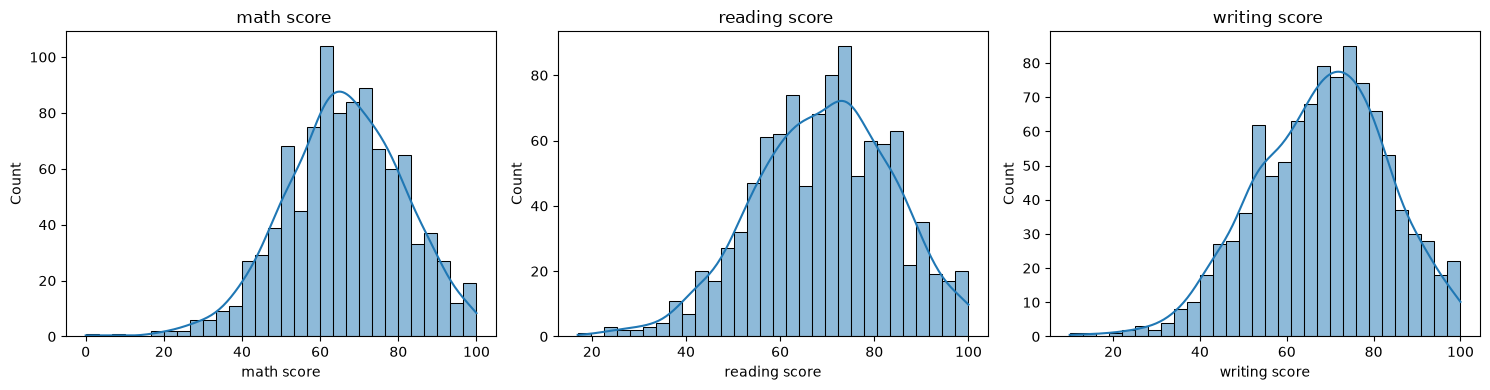

In [13]:
plot_all_histograms(df)

In [14]:
from scipy.stats import skew

In [15]:
df.drop(categorical_cols,axis=1).apply(skew).sort_values(ascending=False)

reading score   -0.258716
math score      -0.278517
writing score   -0.289010
dtype: float64

In [16]:
#There skewness however it is too low to use transformers imo

In [17]:
lunch_map = {
    "free/reduced":0,
    "standard": 1
}

In [18]:
gender_map = {
    "female": 0,
    "male": 1
}

In [19]:
test_prep_course_map = {
    "none": 0,
    "completed": 1
}

In [20]:
df["gender"] = df["gender"].map(gender_map)

In [21]:
df["lunch"] = df["lunch"].map(lunch_map)

In [22]:
df["test preparation course"] = df["test preparation course"].map(test_prep_course_map)

In [23]:
df.head()

,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score
0,0,group B,bachelor's degree,1,0,72,72,74
1,0,group C,some college,1,1,69,90,88
2,0,group B,master's degree,1,0,90,95,93
3,1,group A,associate's degree,0,0,47,57,44
4,1,group C,some college,1,0,76,78,75


In [24]:
def find_outliers_iqr(df, threshold=1.5):
    outlier_summary = {}

    numeric_cols = df.select_dtypes(include=["float64","int64"]).columns

    for col in numeric_cols:
        Q1 = df[col].quantile(0.25)
        Q3 = df[col].quantile(0.75)
        IQR = Q3 - Q1

        lower_bound = Q1 - threshold * IQR
        upper_bound = Q3 + threshold * IQR

        outliers = df[ (df[col]<lower_bound) |  (df[col]> upper_bound)]

        outlier_summary[col] = {
            "outlier_count": outliers.shape[0], 
            "outlier_percentage": 100 * outliers.shape[0] / df.shape[0],
            "lower_bound": lower_bound,
            "upper_bound": upper_bound
        }
        
    return pd.DataFrame(outlier_summary)

In [25]:
info_ = find_outliers_iqr(df)

In [26]:
info_

,gender,lunch,test preparation course,math score,reading score,writing score
outlier_count,0.0,0.0,0.0,8.0,6.0,5.000
outlier_percentage,0.0,0.0,0.0,0.8,0.6,0.500
lower_bound,-1.5,-1.5,-1.5,27.0,29.0,25.875
upper_bound,2.5,2.5,2.5,107.0,109.0,110.875


In [27]:
def remove_outliers_from_column(df,target_col,threshold=1.5):
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1

    lower_bound = Q1 - threshold * IQR
    upper_bound = Q3 + threshold * IQR

    return df[ (df[col]>=lower_bound) &  (df[col] <= upper_bound)]

In [28]:
target_cols = ["math score","reading score", "writing score"]

In [29]:
df.shape

(1000, 8)

In [30]:
df_new = remove_outliers_from_column(df,target_cols)

In [31]:
df_new.shape

(995, 8)

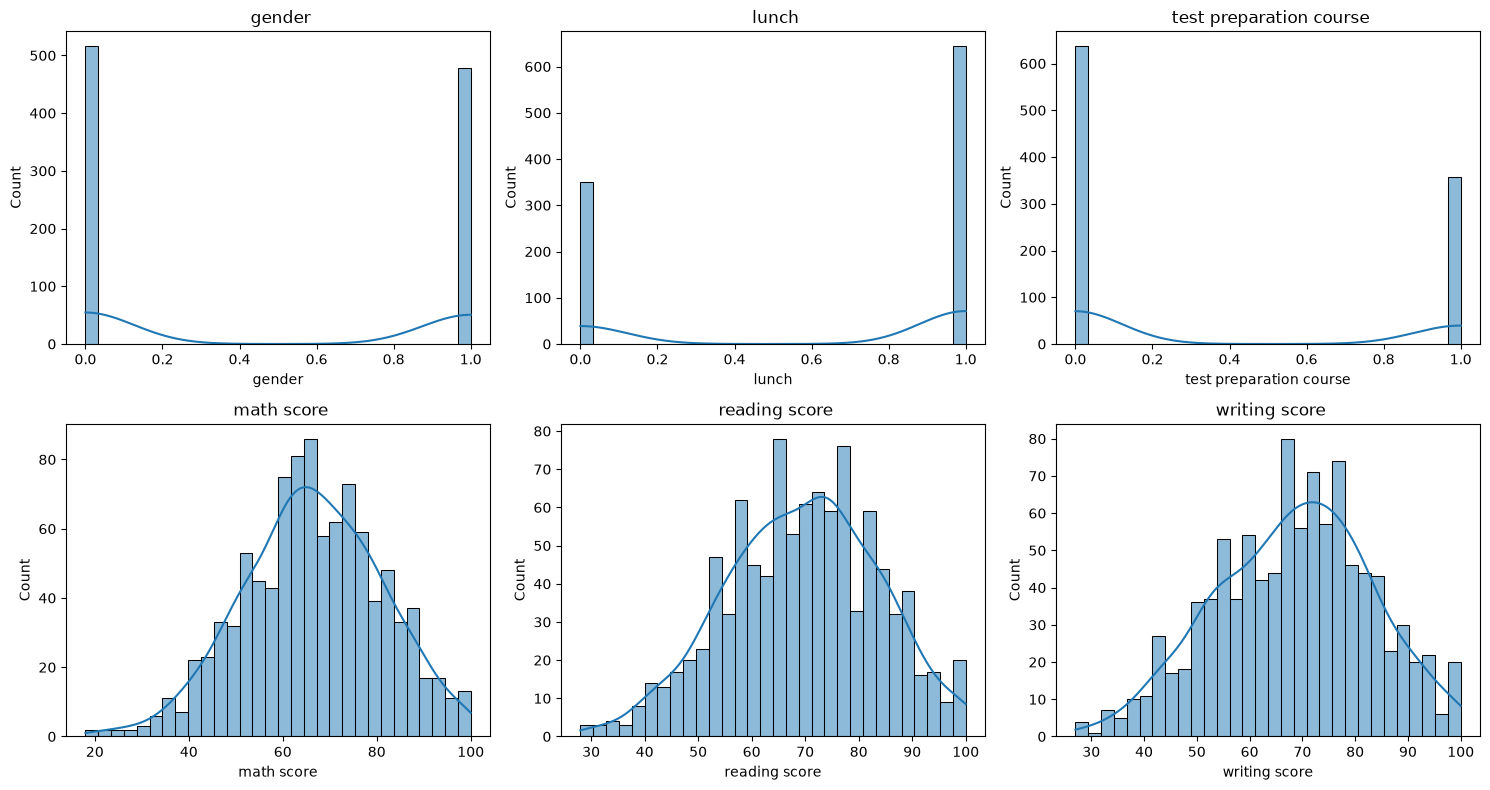

In [32]:
plot_all_histograms(df_new)

In [33]:
df_new.drop(categorical_cols,axis=1).apply(skew).sort_values(ascending=False)

math score      -0.151897
reading score   -0.152800
writing score   -0.162989
dtype: float64

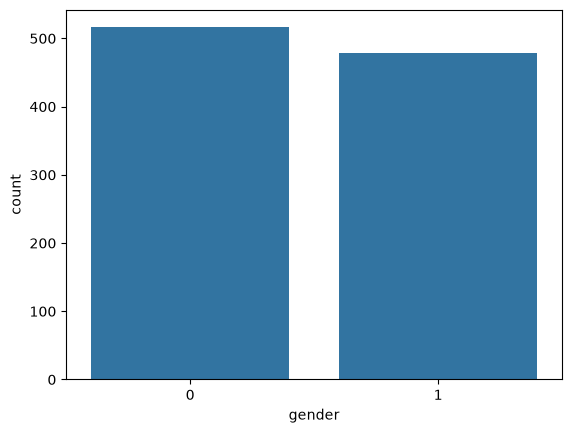

In [34]:
sns.countplot(data=df_new,x="gender")
plt.show()

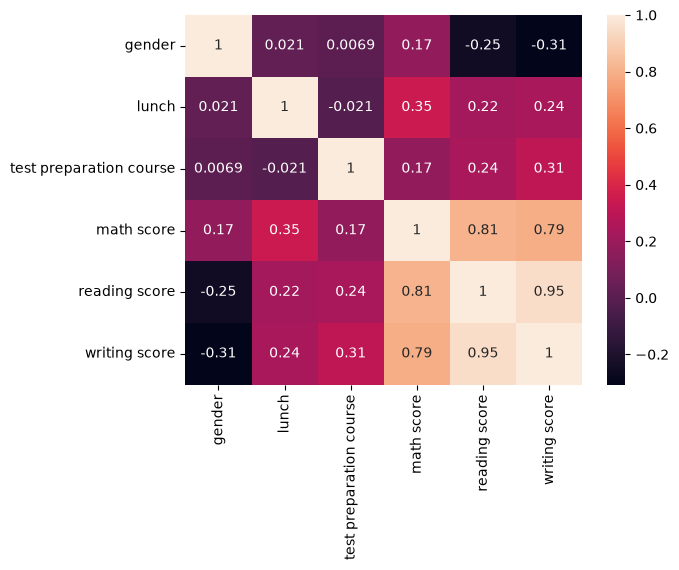

In [35]:
sns.heatmap(df_new.corr(numeric_only=True),annot=True)
plt.show()

In [36]:
# first predict math score

In [37]:
X = df_new.drop(["math score"], axis=1)
y = df_new["math score"]

In [38]:
from sklearn.model_selection import train_test_split

In [39]:
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.25,random_state=15)

In [40]:
from sklearn.preprocessing import OrdinalEncoder

In [41]:
encoders = {}
target_cols = ["race/ethnicity","parental level of education"]
for col in target_cols:
    encoders[col] = OrdinalEncoder()
    X_train[[col]] = encoders[col].fit_transform(X_train[[col]])
    X_test[[col]] = encoders[col].transform(X_test[[col]])

In [42]:
X_train.head()

,gender,race/ethnicity,parental level of education,lunch,test preparation course,reading score,writing score
846,1,2.0,3.0,1,1,85,85
968,0,4.0,0.0,1,0,76,67
193,1,3.0,4.0,1,1,62,62
859,1,2.0,0.0,0,0,73,72
966,1,0.0,5.0,1,1,68,64


In [43]:
from sklearn.preprocessing import StandardScaler

In [44]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [45]:
from sklearn.linear_model import LinearRegression, Lasso, Ridge
from sklearn.neighbors import KNeighborsRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import AdaBoostRegressor,GradientBoostingRegressor,RandomForestRegressor
from sklearn.svm import SVR
import xgboost as xgb
import lightgbm as lgb

In [46]:
from sklearn.metrics import r2_score,mean_absolute_error,mean_squared_error

In [47]:
def evulate_model(true,predicted):
    mae = mean_absolute_error(true,predicted)
    mse = mean_squared_error(true,predicted)
    rmse = np.sqrt(mse)
    score = r2_score(true,predicted)

    return mae,rmse,score

models = {
    "LinearRegression": LinearRegression(),
    "Lasso": Lasso(),
    "Ridge": Ridge(),
    "SVR": SVR(),
    "K Neighbors Regressor": KNeighborsRegressor(),
    "DecisionTreeRegressor": DecisionTreeRegressor(),
    "Random Forest Regressor": RandomForestRegressor(),
    "AdaBoost Regressor": AdaBoostRegressor(),
    "Gradient Boost Regressor": GradientBoostingRegressor(),
    "XGBoost Regressor": xgb.XGBRegressor(),
    "LightGBM Regressor": lgb.LGBMRegressor()
}

for i in range(len(list(models))):
    model = list(models.values())[i]
    model.fit(X_train,y_train)

    y_train_pred = model.predict(X_train)
    y_test_pred = model.predict(X_test)

    model_train_mae,model_train_rmse,model_train_score = evulate_model(y_train,y_train_pred)
    model_test_mae,model_test_rmse,model_test_score = evulate_model(y_test,y_test_pred)

    print(list(models.keys())[i])
    print("Model performance for Traning set")
    print("Root MSE",model_train_rmse)
    print("MAE",model_train_mae)
    print("Score",model_train_score)

    print("---------------------------------")

    print("Model performance for Test set")
    print("Root MSE",model_test_rmse)
    print("MAE",model_test_mae)
    print("Score",model_test_score)
    print("\n")

LinearRegression
Model performance for Traning set
Root MSE 5.509976522210177
MAE 4.426148134330572
Score 0.864187752713846
---------------------------------
Model performance for Test set
Root MSE 5.60453427074429
MAE 4.3914864091982295
Score 0.8467844837663158


Lasso
Model performance for Traning set
Root MSE 6.367649414271807
MAE 5.040328848195178
Score 0.8186165210470026
---------------------------------
Model performance for Test set
Root MSE 6.255756585712303
MAE 4.9057193324141695
Score 0.8091099137894191


Ridge
Model performance for Traning set
Root MSE 5.510123479443572
MAE 4.425402740933363
Score 0.8641805080883196
---------------------------------
Model performance for Test set
Root MSE 5.602207665614796
MAE 4.390713890194535
Score 0.8469116657935185


SVR
Model performance for Traning set
Root MSE 9.063263087795663
MAE 7.352091487386679
Score 0.6325412337468768
---------------------------------
Model performance for Test set
Root MSE 8.713968233807538
MAE 6.96112177758269

In [48]:
models_for_tuning = {
    "Random Forest Regressor": RandomForestRegressor(),
    "Gradient Boost Regressor": GradientBoostingRegressor(),
    "XGBoost Regressor": xgb.XGBRegressor(),
    "LightGBM Regressor": lgb.LGBMRegressor()
}

In [49]:
from sklearn.model_selection import RandomizedSearchCV

In [50]:
random_forest_params = {
    "n_estimators": [100, 200, 300, 500],
    "max_depth": [None, 5, 10, 15, 20],
    "min_samples_split": [2, 5, 10],
    "min_samples_leaf": [1, 2, 4],
    "max_features": ["sqrt", "log2"],
    "bootstrap": [True, False]
}

In [51]:
gradient_boost_params = {
    "n_estimators": [100, 200, 300],
    "learning_rate": [0.01, 0.05, 0.1, 0.2],
    "max_depth": [2, 3, 4, 5],
    "min_samples_split": [2, 5, 10],
    "min_samples_leaf": [1, 2, 4],
    "subsample": [0.8, 0.9, 1.0]
}

In [52]:
xgboost_params = {
    "n_estimators": [100, 200, 300],
    "learning_rate": [0.01, 0.05, 0.1],
    "max_depth": [3, 4, 5, 6],
    "min_child_weight": [1, 3, 5],
    "subsample": [0.8, 0.9, 1.0],
    "colsample_bytree": [0.8, 0.9, 1.0],
    "gamma": [0, 0.1, 0.3]
}

In [53]:
lightgbm_params = {
    "n_estimators": [100, 200, 300],
    "learning_rate": [0.01, 0.05, 0.1],
    "num_leaves": [15, 31, 63],
    "max_depth": [-1, 5, 10],
    "min_child_samples": [10, 20, 30],
    "subsample": [0.8, 0.9, 1.0],
    "colsample_bytree": [0.8, 0.9, 1.0]
}

In [54]:
params = {
    "Random Forest Regressor": random_forest_params,
    "Gradient Boost Regressor": gradient_boost_params,
    "XGBoost Regressor": xgboost_params,
    "LightGBM Regressor": lightgbm_params
}

for i in range(len(list(models_for_tuning))):

    model_name = list(models_for_tuning.keys())[i]
    model = list(models_for_tuning.values())[i]

    random_search = RandomizedSearchCV(
        estimator=model,
        param_distributions=params[model_name],
        n_iter=50,
        cv=5,
        scoring="r2",
        random_state=42,
        n_jobs=-1
    )

    random_search.fit(X_train, y_train)

    best_model = random_search.best_estimator_

    y_train_pred = best_model.predict(X_train)
    y_test_pred = best_model.predict(X_test)

    model_train_mae, model_train_rmse, model_train_score = evulate_model(y_train, y_train_pred)
    model_test_mae, model_test_rmse, model_test_score = evulate_model(y_test, y_test_pred)

    print(model_name)
    print("Best Parameters:", random_search.best_params_)
    print()

    print("Model performance for Training set")
    print("Root MSE", model_train_rmse)
    print("MAE", model_train_mae)
    print("Score", model_train_score)

    print("---------------------------------")

    print("Model performance for Test set")
    print("Root MSE", model_test_rmse)
    print("MAE", model_test_mae)
    print("Score", model_test_score)
    print("\n")

Random Forest Regressor
Best Parameters: {'n_estimators': 100, 'min_samples_split': 5, 'min_samples_leaf': 4, 'max_features': 'log2', 'max_depth': 20, 'bootstrap': False}

Model performance for Training set
Root MSE 4.111732165766068
MAE 3.268915217001064
Score 0.9243708753775591
---------------------------------
Model performance for Test set
Root MSE 5.9524749002840105
MAE 4.68096697815607
Score 0.8271701169326574


Gradient Boost Regressor
Best Parameters: {'subsample': 0.8, 'n_estimators': 200, 'min_samples_split': 5, 'min_samples_leaf': 2, 'max_depth': 2, 'learning_rate': 0.05}

Model performance for Training set
Root MSE 4.988317957171324
MAE 4.021100683351858
Score 0.8886865368982599
---------------------------------
Model performance for Test set
Root MSE 5.476076599614527
MAE 4.295275421092505
Score 0.8537274881313821


XGBoost Regressor
Best Parameters: {'subsample': 0.8, 'n_estimators': 100, 'min_child_weight': 5, 'max_depth': 4, 'learning_rate': 0.05, 'gamma': 0, 'colsample

In [55]:
best_model = GradientBoostingRegressor(
    subsample=0.8,
    n_estimators=200,
    min_samples_split=2,
    min_samples_leaf=4,
    max_depth=2,
    learning_rate=0.05,
    random_state=42
)

best_model.fit(X_train, y_train)

,"learning_rate learning_rate: float, default=0.1Learning rate shrinks the contribution of each tree by `learning_rate`.There is a trade-off between learning_rate and n_estimators.Values must be in the range `[0.0, inf)`.",0.05
,"n_estimators n_estimators: int, default=100The number of boosting stages to perform. Gradient boostingis fairly robust to over-fitting so a large number usuallyresults in better performance.Values must be in the range `[1, inf)`.",200
,"subsample subsample: float, default=1.0The fraction of samples to be used for fitting the individual baselearners. If smaller than 1.0 this results in Stochastic GradientBoosting. `subsample` interacts with the parameter `n_estimators`.Choosing `subsample < 1.0` leads to a reduction of varianceand an increase in bias.Values must be in the range `(0.0, 1.0]`.",0.8
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, values must be in the range `[1, inf)`.- If float, values must be in the range `(0.0, 1.0)` and `min_samples_leaf` will be `ceil(min_samples_leaf * n_samples)`... versionchanged:: 0.18 Added float values for fractions.",4
,"max_depth max_depth: int or None, default=3Maximum depth of the individual regression estimators. The maximumdepth limits the number of nodes in the tree. Tune this parameterfor best performance; the best value depends on the interactionof the input variables. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.If int, values must be in the range `[1, inf)`.",2
,"random_state random_state: int, RandomState instance or None, default=NoneControls the random seed given to each Tree estimator at eachboosting iteration.In addition, it controls the random permutation of the features ateach split (see Notes for more details).It also controls the random splitting of the training data to obtain avalidation set if `n_iter_no_change` is not None.Pass an int for reproducible output across multiple function calls.See :term:`Glossary <random_state>`.",42
,"loss loss: {'squared_error', 'absolute_error', 'huber', 'quantile'}, default='squared_error'Loss function to be optimized. 'squared_error' refers to the squarederror for regression. 'absolute_error' refers to the absolute error ofregression and is a robust loss function. 'huber' is acombination of the two. 'quantile' allows quantile regression (use`alpha` to specify the quantile).See:ref:`sphx_glr_auto_examples_ensemble_plot_gradient_boosting_quantile.py`for an example that demonstrates quantile regression for creatingprediction intervals with `loss='quantile'`.",'squared_error'
,"criterion criterion: {'friedman_mse', 'squared_error'}, default='friedman_mse'This parameter has no effect... versionadded:: 0.18.. deprecated:: 1.9 `criterion` is deprecated and will be removed in 1.11.",'deprecated'
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, values must be in the range `[2, inf)`.- If float, values must be in the range `(0.0, 1.0]` and `min_samples_split` will be `ceil(min_samples_split * n_samples)`... versionchanged:: 0.18 Added float values for fractions.",2
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.Values must be in the range `[0.0, 0.5]`.",0.0
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.Values must be in the range `[0.0, in

In [66]:
import pickle

In [69]:
with open("closing_project.pkl","wb") as f:
    pickle.dump(
        {
            "model": best_model,
            "encoders": encoders,
            "scaler": scaler,
            "maps": [lunch_map,gender_map,test_prep_course_map]
        }
    ,f)

In [70]:
pd.DataFrame(X_test_scaled).to_csv("test_data.csv",index=False)

In [64]:
# Now for reading score regressor

In [65]:
X = df_new.drop("reading score",axis=1)
y = df_new["reading score"]

In [71]:
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.25,random_state=15)

In [72]:
encoders = {}
target_cols = ["race/ethnicity","parental level of education"]
for col in target_cols:
    encoders[col] = OrdinalEncoder()
    X_train[[col]] = encoders[col].fit_transform(X_train[[col]])
    X_test[[col]] = encoders[col].transform(X_test[[col]])

In [73]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [74]:
def evulate_model(true,predicted):
    mae = mean_absolute_error(true,predicted)
    mse = mean_squared_error(true,predicted)
    rmse = np.sqrt(mse)
    score = r2_score(true,predicted)

    return mae,rmse,score

models = {
    "LinearRegression": LinearRegression(),
    "Lasso": Lasso(),
    "Ridge": Ridge(),
    "SVR": SVR(),
    "K Neighbors Regressor": KNeighborsRegressor(),
    "DecisionTreeRegressor": DecisionTreeRegressor(),
    "Random Forest Regressor": RandomForestRegressor(),
    "AdaBoost Regressor": AdaBoostRegressor(),
    "Gradient Boost Regressor": GradientBoostingRegressor(),
    "XGBoost Regressor": xgb.XGBRegressor(),
    "LightGBM Regressor": lgb.LGBMRegressor()
}

for i in range(len(list(models))):
    model = list(models.values())[i]
    model.fit(X_train,y_train)

    y_train_pred = model.predict(X_train)
    y_test_pred = model.predict(X_test)

    model_train_mae,model_train_rmse,model_train_score = evulate_model(y_train,y_train_pred)
    model_test_mae,model_test_rmse,model_test_score = evulate_model(y_test,y_test_pred)

    print(list(models.keys())[i])
    print("Model performance for Traning set")
    print("Root MSE",model_train_rmse)
    print("MAE",model_train_mae)
    print("Score",model_train_score)

    print("---------------------------------")

    print("Model performance for Test set")
    print("Root MSE",model_test_rmse)
    print("MAE",model_test_mae)
    print("Score",model_test_score)
    print("\n")

LinearRegression
Model performance for Traning set
Root MSE 4.06415063421532
MAE 3.261370869704462
Score 0.9196194008142665
---------------------------------
Model performance for Test set
Root MSE 4.026321712835121
MAE 3.325293168394022
Score 0.9171378358665748


Lasso
Model performance for Traning set
Root MSE 4.194486091427232
MAE 3.3691266502537403
Score 0.9143811946233229
---------------------------------
Model performance for Test set
Root MSE 4.101665487961646
MAE 3.333599358111935
Score 0.9140076529750976


Ridge
Model performance for Traning set
Root MSE 4.064156140101233
MAE 3.261486770668907
Score 0.919619183023762
---------------------------------
Model performance for Test set
Root MSE 4.025876745010826
MAE 3.324757398902961
Score 0.9171561498325846


SVR
Model performance for Traning set
Root MSE 4.683834943724555
MAE 3.7201457220950975
Score 0.8932384645371834
---------------------------------
Model performance for Test set
Root MSE 4.602751915544276
MAE 3.81936758597224

In [75]:
#Ridge selected

In [76]:
best_model = Ridge()

In [77]:
with open("closing_project_reading_score.pkl","wb") as f:
    pickle.dump({
        "model": best_model,
        "encoders": encoders,
        "scaler": scaler,
        "maps": [lunch_map,gender_map,test_prep_course_map]
    },f)

In [78]:
pd.DataFrame(X_test_scaled).to_csv("test_data_reading_score.csv",index=False)

In [79]:
# Now time for writing score 

In [80]:
X = df_new.drop("writing score", axis=1)
y = df_new["writing score"]

In [81]:
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.25,random_state=15)

In [82]:
encoders = {}
target_cols = ["race/ethnicity","parental level of education"]
for col in target_cols:
    encoders[col] = OrdinalEncoder()
    X_train[[col]] = encoders[col].fit_transform(X_train[[col]])
    X_test[[col]] = encoders[col].transform(X_test[[col]])

In [83]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [84]:
models = {
    "LinearRegression": LinearRegression(),
    "Lasso": Lasso(),
    "Ridge": Ridge(),
    "SVR": SVR(),
    "K Neighbors Regressor": KNeighborsRegressor(),
    "DecisionTreeRegressor": DecisionTreeRegressor(),
    "Random Forest Regressor": RandomForestRegressor(),
    "AdaBoost Regressor": AdaBoostRegressor(),
    "Gradient Boost Regressor": GradientBoostingRegressor(),
    "XGBoost Regressor": xgb.XGBRegressor(),
    "LightGBM Regressor": lgb.LGBMRegressor()
}

for i in range(len(list(models))):
    model = list(models.values())[i]
    model.fit(X_train,y_train)

    y_train_pred = model.predict(X_train)
    y_test_pred = model.predict(X_test)

    model_train_mae,model_train_rmse,model_train_score = evulate_model(y_train,y_train_pred)
    model_test_mae,model_test_rmse,model_test_score = evulate_model(y_test,y_test_pred)

    print(list(models.keys())[i])
    print("Model performance for Traning set")
    print("Root MSE",model_train_rmse)
    print("MAE",model_train_mae)
    print("Score",model_train_score)

    print("---------------------------------")

    print("Model performance for Test set")
    print("Root MSE",model_test_rmse)
    print("MAE",model_test_mae)
    print("Score",model_test_score)
    print("\n")

LinearRegression
Model performance for Traning set
Root MSE 3.6729279847612393
MAE 2.967328309053093
Score 0.9386290039229623
---------------------------------
Model performance for Test set
Root MSE 3.872629308722651
MAE 3.1140002758369563
Score 0.9306895527754384


Lasso
Model performance for Traning set
Root MSE 4.468351472107262
MAE 3.5912134372553868
Score 0.9091692293688562
---------------------------------
Model performance for Test set
Root MSE 4.544981270319522
MAE 3.610264649444911
Score 0.9045334911586738


Ridge
Model performance for Traning set
Root MSE 3.673010361628116
MAE 2.9677216968170956
Score 0.9386262510200531
---------------------------------
Model performance for Test set
Root MSE 3.872046911154319
MAE 3.1125671129426458
Score 0.9307103981481317


SVR
Model performance for Traning set
Root MSE 5.02532796870176
MAE 4.077797125446221
Score 0.8851139847134692
---------------------------------
Model performance for Test set
Root MSE 5.15674324152268
MAE 4.18840345907

In [85]:
#Ridge selected

In [86]:
best_model = Ridge()

In [90]:
with open("closing_project_writing_score.pkl","wb") as f:
    pickle.dump(
        {
            "model": best_model,
            "encoders": encoders,
            "scaler": scaler,
            "maps": [lunch_map,gender_map,test_prep_course_map]
        }
    ,f)

In [91]:
pd.DataFrame(X_test_scaled).to_csv("test_data_writing_score.csv",index=False)